<a href="https://colab.research.google.com/github/sabeervc/Sabeervc/blob/main/Marriage_ID_probability_India.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

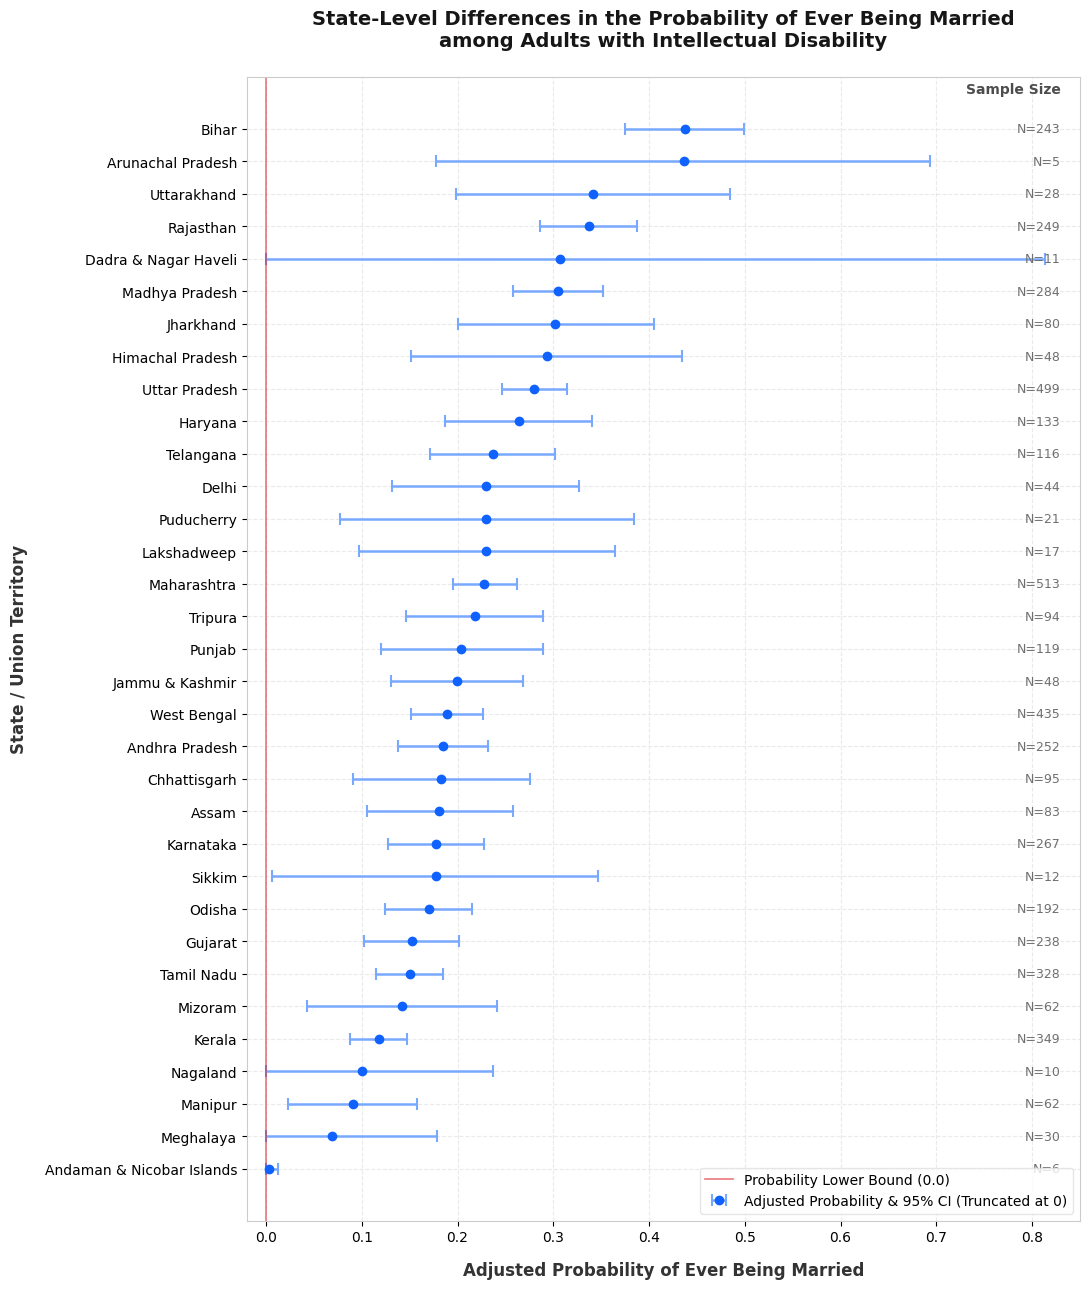

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Input Dataset (Negative 95% CI values truncated to 0.000)
data = [
    {"state": "Jammu & Kashmir", "prob": 0.199, "ci_lower": 0.130, "ci_upper": 0.268, "n": 48},
    {"state": "Himachal Pradesh", "prob": 0.293, "ci_lower": 0.151, "ci_upper": 0.434, "n": 48},
    {"state": "Punjab", "prob": 0.204, "ci_lower": 0.120, "ci_upper": 0.289, "n": 119},
    {"state": "Uttarakhand", "prob": 0.341, "ci_lower": 0.198, "ci_upper": 0.484, "n": 28},
    {"state": "Haryana", "prob": 0.264, "ci_lower": 0.187, "ci_upper": 0.340, "n": 133},
    {"state": "Delhi", "prob": 0.230, "ci_lower": 0.132, "ci_upper": 0.327, "n": 44},
    {"state": "Rajasthan", "prob": 0.337, "ci_lower": 0.286, "ci_upper": 0.387, "n": 249},
    {"state": "Uttar Pradesh", "prob": 0.280, "ci_lower": 0.246, "ci_upper": 0.314, "n": 499},
    {"state": "Bihar", "prob": 0.437, "ci_lower": 0.375, "ci_upper": 0.499, "n": 243},
    {"state": "Sikkim", "prob": 0.177, "ci_lower": 0.006, "ci_upper": 0.347, "n": 12},
    {"state": "Arunachal Pradesh", "prob": 0.436, "ci_lower": 0.178, "ci_upper": 0.693, "n": 5},
    {"state": "Nagaland", "prob": 0.100, "ci_lower": 0.000, "ci_upper": 0.237, "n": 10},
    {"state": "Manipur", "prob": 0.091, "ci_lower": 0.023, "ci_upper": 0.158, "n": 62},
    {"state": "Mizoram", "prob": 0.142, "ci_lower": 0.043, "ci_upper": 0.241, "n": 62},
    {"state": "Tripura", "prob": 0.218, "ci_lower": 0.146, "ci_upper": 0.289, "n": 94},
    {"state": "Meghalaya", "prob": 0.069, "ci_lower": 0.000, "ci_upper": 0.179, "n": 30},
    {"state": "Assam", "prob": 0.181, "ci_lower": 0.105, "ci_upper": 0.258, "n": 83},
    {"state": "West Bengal", "prob": 0.189, "ci_lower": 0.151, "ci_upper": 0.227, "n": 435},
    {"state": "Jharkhand", "prob": 0.302, "ci_lower": 0.200, "ci_upper": 0.405, "n": 80},
    {"state": "Odisha", "prob": 0.170, "ci_lower": 0.124, "ci_upper": 0.215, "n": 192},
    {"state": "Chhattisgarh", "prob": 0.183, "ci_lower": 0.091, "ci_upper": 0.276, "n": 95},
    {"state": "Madhya Pradesh", "prob": 0.305, "ci_lower": 0.258, "ci_upper": 0.352, "n": 284},
    {"state": "Gujarat", "prob": 0.152, "ci_lower": 0.102, "ci_upper": 0.202, "n": 238},
    {"state": "Dadra & Nagar Haveli", "prob": 0.307, "ci_lower": 0.000, "ci_upper": 0.813, "n": 11},
    {"state": "Maharashtra", "prob": 0.228, "ci_lower": 0.195, "ci_upper": 0.262, "n": 513},
    {"state": "Andhra Pradesh", "prob": 0.185, "ci_lower": 0.138, "ci_upper": 0.232, "n": 252},
    {"state": "Karnataka", "prob": 0.178, "ci_lower": 0.127, "ci_upper": 0.228, "n": 267},
    {"state": "Lakshadweep", "prob": 0.230, "ci_lower": 0.097, "ci_upper": 0.364, "n": 17},
    {"state": "Kerala", "prob": 0.118, "ci_lower": 0.088, "ci_upper": 0.147, "n": 349},
    {"state": "Tamil Nadu", "prob": 0.150, "ci_lower": 0.115, "ci_upper": 0.185, "n": 328},
    {"state": "Puducherry", "prob": 0.230, "ci_lower": 0.077, "ci_upper": 0.384, "n": 21},
    {"state": "Andaman & Nicobar Islands", "prob": 0.003, "ci_lower": 0.000, "ci_upper": 0.012, "n": 6},
    {"state": "Telangana", "prob": 0.237, "ci_lower": 0.171, "ci_upper": 0.302, "n": 116}
]

# 2. Process and sort data by Adjusted Probability
df = pd.DataFrame(data)
df = df.sort_values(by="prob", ascending=True).reset_index(drop=True)

# 3. Configure plot dimensions and layout
plt.rcParams.update({
    "font.family": "sans-serif",
    "figure.figsize": (11, 13),
    "axes.edgecolor": "#cccccc",
    "axes.linewidth": 0.8
})

fig, ax = plt.subplots()

# 4. Compute asymmetric errors based on the truncated bounds
error_left = df['prob'] - df['ci_lower']
error_right = df['ci_upper'] - df['prob']
errors = np.array([error_left, error_right])

# Ensure gridlines sit behind plot elements
ax.set_axisbelow(True)
ax.grid(True, linestyle='--', color='#e2e2e2', alpha=0.7)

# 5. Generate Forest Plot
ax.errorbar(df['prob'], df['state'], xerr=errors, fmt='o', color='#0f62fe',
            ecolor='#78a9ff', elinewidth=1.8, capsize=4, capthick=1.5,
            ms=6, label='Adjusted Probability & 95% CI (Truncated at 0)')

# 6. Format Axis Labels & Titles
ax.set_xlabel('Adjusted Probability of Ever Being Married', fontsize=12, labelpad=12, fontweight='bold', color='#333333')
ax.set_ylabel('State / Union Territory', fontsize=12, labelpad=12, fontweight='bold', color='#333333')
ax.set_title('State-Level Differences in the Probability of Ever Being Married\namong Adults with Intellectual Disability',
             fontsize=14, pad=22, fontweight='bold', color='#161616', loc='center')

# 7. Add baseline threshold line at probability 0
ax.axvline(x=0, color='#da1e28', linestyle='-', alpha=0.6, linewidth=1.2, label='Probability Lower Bound (0.0)')

# Set appropriate X limits to handle truncated intervals gracefully
ax.set_xlim(-0.02, 0.85)

# 8. Annotate Sample Size (N) values on the right margin
for idx, row in df.iterrows():
    ax.text(0.83, idx, f"N={int(row['n'])}", va='center', ha='right', fontsize=9, color='#6f6f6f')

# Title header for the sample size column
ax.text(0.83, len(df), "Sample Size", va='bottom', ha='right', fontsize=10, fontweight='bold', color='#4d4d4d')

# Render legend
ax.legend(loc='lower right', frameon=True, facecolor='#ffffff', edgecolor='#e0e0e0', fontsize=10)

plt.tight_layout()
plt.savefig("adjusted_probability_truncated_plot.png", dpi=300)
plt.show()

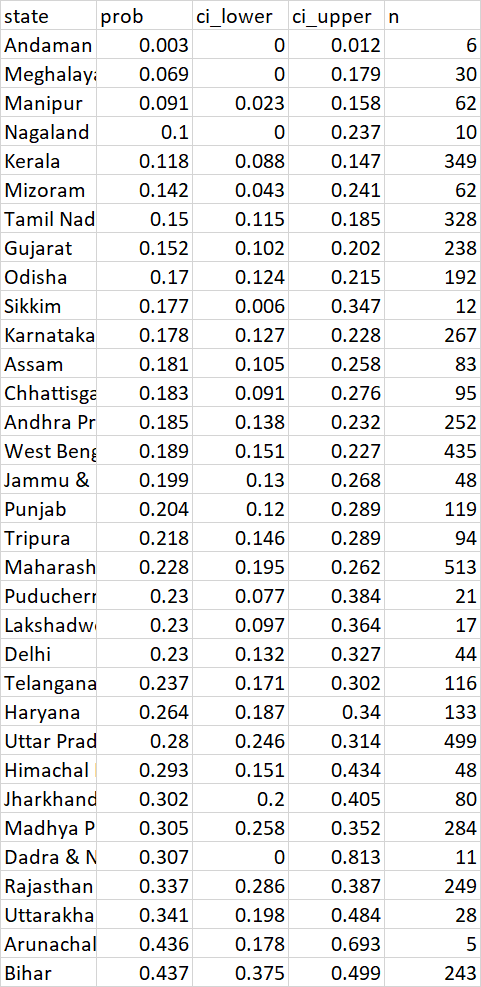

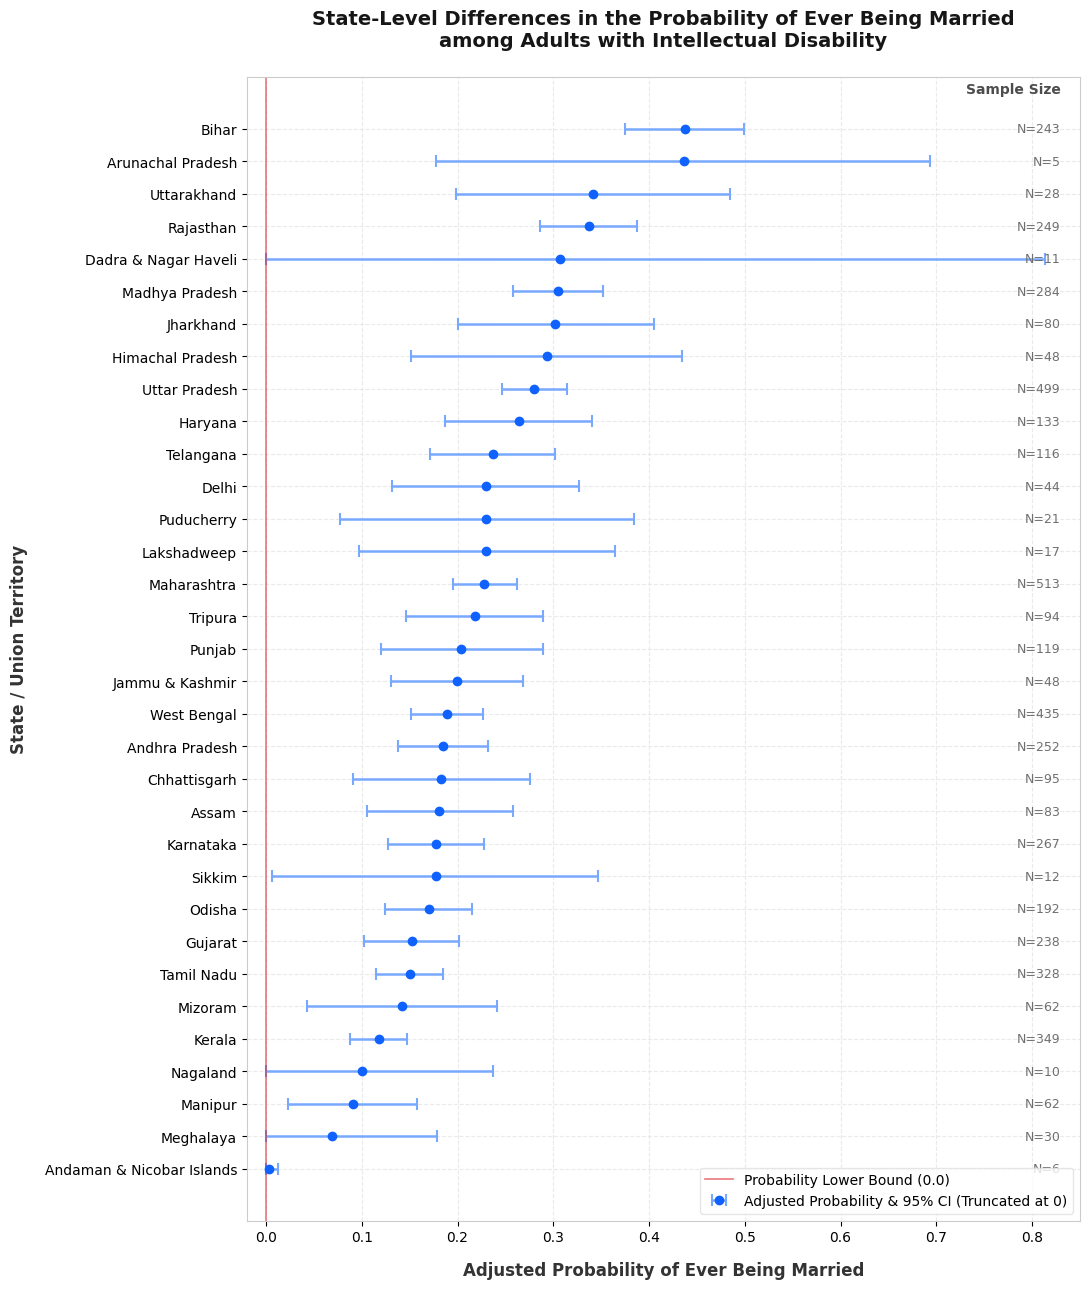

In [3]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Paste your raw text data directly into this multi-line string variable
raw_data = """state,prob,ci_lower,ci_upper,n
Jammu & Kashmir,0.199,0.130,0.268,48
Himachal Pradesh,0.293,0.151,0.434,48
Punjab,0.204,0.120,0.289,119
Uttarakhand,0.341,0.198,0.484,28
Haryana,0.264,0.187,0.340,133
Delhi,0.230,0.132,0.327,44
Rajasthan,0.337,0.286,0.387,249
Uttar Pradesh,0.280,0.246,0.314,499
Bihar,0.437,0.375,0.499,243
Sikkim,0.177,0.006,0.347,12
Arunachal Pradesh,0.436,0.178,0.693,5
Nagaland,0.100,0.000,0.237,10
Manipur,0.091,0.023,0.158,62
Mizoram,0.142,0.043,0.241,62
Tripura,0.218,0.146,0.289,94
Meghalaya,0.069,0.000,0.179,30
Assam,0.181,0.105,0.258,83
West Bengal,0.189,0.151,0.227,435
Jharkhand,0.302,0.200,0.405,80
Odisha,0.170,0.124,0.215,192
Chhattisgarh,0.183,0.091,0.276,95
Madhya Pradesh,0.305,0.258,0.352,284
Gujarat,0.152,0.102,0.202,238
Dadra & Nagar Haveli,0.307,0.000,0.813,11
Maharashtra,0.228,0.195,0.262,513
Andhra Pradesh,0.185,0.138,0.232,252
Karnataka,0.178,0.127,0.228,267
Lakshadweep,0.230,0.097,0.364,17
Kerala,0.118,0.088,0.147,349
Tamil Nadu,0.150,0.115,0.185,328
Puducherry,0.230,0.077,0.384,21
Andaman & Nicobar Islands,0.003,0.000,0.012,6
Telangana,0.237,0.171,0.302,116"""

# 2. Use io.StringIO to read the text data directly as a DataFrame
df = pd.read_csv(io.StringIO(raw_data.strip()))

# 3. Process and sort data dynamically by Adjusted Probability
df = df.sort_values(by="prob", ascending=True).reset_index(drop=True)

# 4. Configure plot dimensions and layout styling for Jupyter
plt.rcParams.update({
    "font.family": "sans-serif",
    "figure.figsize": (11, 13),
    "axes.edgecolor": "#cccccc",
    "axes.linewidth": 0.8
})

fig, ax = plt.subplots()

# 5. Compute asymmetric error boundaries based on the truncated bounds
error_left = df['prob'] - df['ci_lower']
error_right = df['ci_upper'] - df['prob']
errors = np.array([error_left, error_right])

# Ensure gridlines sit visually behind the plot points and error bars
ax.set_axisbelow(True)
ax.grid(True, linestyle='--', color='#e2e2e2', alpha=0.7)

# 6. Generate the Forest Plot
ax.errorbar(df['prob'], df['state'], xerr=errors, fmt='o', color='#0f62fe',
            ecolor='#78a9ff', elinewidth=1.8, capsize=4, capthick=1.5,
            ms=6, label='Adjusted Probability & 95% CI (Truncated at 0)')

# 7. Format Axis Labels & Titles
ax.set_xlabel('Adjusted Probability of Ever Being Married', fontsize=12, labelpad=12, fontweight='bold', color='#333333')
ax.set_ylabel('State / Union Territory', fontsize=12, labelpad=12, fontweight='bold', color='#333333')
ax.set_title('State-Level Differences in the Probability of Ever Being Married\namong Adults with Intellectual Disability',
             fontsize=14, pad=22, fontweight='bold', color='#161616', loc='center')

# 8. Add baseline threshold line at probability 0
ax.axvline(x=0, color='#da1e28', linestyle='-', alpha=0.6, linewidth=1.2, label='Probability Lower Bound (0.0)')

# Set X limits to handle truncated intervals cleanly
ax.set_xlim(-0.02, 0.85)

# 9. Annotate Sample Size (N) values on the right margin dynamically
for idx, row in df.iterrows():
    ax.text(0.83, idx, f"N={int(row['n'])}", va='center', ha='right', fontsize=9, color='#6f6f6f')

# Title header for the sample size column alignment
ax.text(0.83, len(df), "Sample Size", va='bottom', ha='right', fontsize=10, fontweight='bold', color='#4d4d4d')

# Render legend block
ax.legend(loc='lower right', frameon=True, facecolor='#ffffff', edgecolor='#e0e0e0', fontsize=10)

plt.tight_layout()

# Save output image file to your workspace
plt.savefig("adjusted_probability_forest_plot.png", dpi=300)

# Explicitly display the plot inside the Notebook cell
plt.show()